In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
matches = pd.read_csv("../data/processed/matches_with_features.csv")
matches["home_win_binary"] = (matches["result"] == "home_win").astype(int)
X = matches["elo_difference"].values
y = matches["home_win_binary"].values

In [6]:
def sigmoid(x):
    return 1/(1+np.exp(-x))
print(sigmoid(-10))
print(sigmoid(0))
print(sigmoid(10))

4.5397868702434395e-05
0.5
0.9999546021312976


In [9]:
weight = 0.0
bias = 0.0
raw_scores = weight * X + bias
probabilities = sigmoid(raw_scores)
print(probabilities[:10])
predictions = (probabilities >= 0.5).astype(int)
def cross_entropy_loss(y_true, y_prob):
    epsilon = 1e-15

    y_prob = np.clip(y_prob, epsilon, 1 - epsilon)

    loss = -np.mean(
        y_true * np.log(y_prob)
        + (1 - y_true) * np.log(1 - y_prob)
    )

    return loss
loss = cross_entropy_loss(y, probabilities)
print(loss)

[0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]
0.6931471805599452


In [11]:
weight_gradient = np.mean((probabilities - y) * X)
bias_gradient = np.mean(probabilities - y)

print("Weight Gradient:", weight_gradient)
print("Bias Gradient:", bias_gradient)

learning_rate = 0.0001
weight = weight - learning_rate * weight_gradient

bias = bias - learning_rate * bias_gradient

print("Loss:", loss)
print("Weight:", weight)
print("Bias:", bias)

Weight Gradient: -43.85687784545477
Bias Gradient: 0.010101826410214967
Loss: 0.6931471805599452
Weight: 0.004385687784545477
Bias: -1.0101826410214968e-06


In [12]:
weight = 0.0
bias = 0.0

learning_rate = 0.0001
epochs = 1000
loss_history = []

for epoch in range(epochs):

    raw_scores = weight * X + bias
    probabilities = sigmoid(raw_scores)

    loss = cross_entropy_loss(y, probabilities)

    weight_gradient = np.mean((probabilities - y) * X)
    bias_gradient = np.mean(probabilities - y)

    weight -= learning_rate * weight_gradient
    bias -= learning_rate * bias_gradient

    loss_history.append(loss)

    print("Final Weight:", weight)
    print("Final Bias:", bias)


Final Weight: 0.004385687784545477
Final Bias: -1.0101826410214968e-06
Final Weight: 0.005223157721962644
Final Bias: -3.1557051527416673e-06
Final Weight: 0.005602877413331611
Final Bias: -5.461902373849739e-06
Final Weight: 0.005795727283453416
Final Bias: -7.834921679297678e-06
Final Weight: 0.0058982464715390025
Final Bias: -1.0240487212258795e-05
Final Weight: 0.005953953303288554
Final Bias: -1.2662966387260739e-05
Final Weight: 0.005984567784455649
Final Bias: -1.5094509197264912e-05
Final Weight: 0.006001494692340535
Final Bias: -1.7530980111493325e-05
Final Weight: 0.006010884749576821
Final Bias: -1.997014473543299e-05
Final Weight: 0.006016103437141707
Final Bias: -2.241077924261759e-05
Final Weight: 0.0060190069009449535
Final Bias: -2.4852208279399544e-05
Final Weight: 0.006020623343840822
Final Bias: -2.7294057616498896e-05
Final Weight: 0.006021523717939301
Final Bias: -2.9736119409172303e-05
Final Weight: 0.006022025495785978
Final Bias: -3.217827807482773e-05
Final Wei

Initial Loss: 0.6931471805599452
Final Loss: 0.5786783180688648


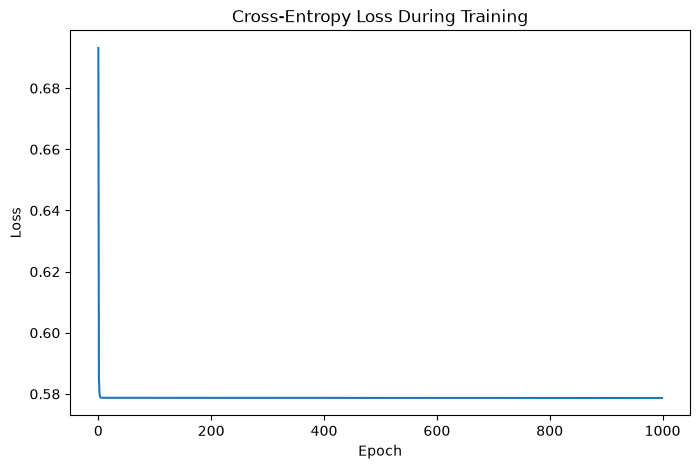

In [14]:
print("Initial Loss:", loss_history[0])
print("Final Loss:", loss_history[-1])
plt.figure(figsize=(8,5))

plt.plot(loss_history)

plt.title("Cross-Entropy Loss During Training")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.show()

In [16]:
raw_scores = weight * X + bias

probabilities = sigmoid(raw_scores)

predictions = (probabilities >= 0.5).astype(int)
accuracy = np.mean(predictions == y)

print("Accuracy:", accuracy)

Accuracy: 0.688156618716664


In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X_sklearn = X.reshape(-1, 1)

sklearn_model = LogisticRegression(max_iter=1000)

sklearn_model.fit(X_sklearn, y)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [20]:
sklearn_probabilities = sklearn_model.predict_proba(X_sklearn)[:, 1]

sklearn_predictions = sklearn_model.predict(X_sklearn)

sklearn_accuracy = accuracy_score(y, sklearn_predictions)

print("sklearn accuracy:", sklearn_accuracy)
our_accuracy = np.mean(predictions == y)

print("Our accuracy:", our_accuracy)
print("sklearn accuracy:", sklearn_accuracy)
print("Our weight:", weight)
print("Our bias:", bias)

print("sklearn weight:", sklearn_model.coef_[0][0])
print("sklearn bias:", sklearn_model.intercept_[0])

sklearn accuracy: 0.6894900598028123
Our accuracy: 0.688156618716664
sklearn accuracy: 0.6894900598028123
Our weight: 0.006023530669677724
Our bias: -0.0024169952067944053
sklearn weight: 0.006087199939265926
sklearn bias: -0.12416341955057895
